In [1]:
import torch
import torchvision

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.14.1+cpu
Torchvision: 0.29.1+cpu


In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [3]:
from pathlib import Path

classification_dir = Path(
    "../data/processed/classification_preprocessed"
)

train_dir = classification_dir / "train"
val_dir = classification_dir / "val"
test_dir = classification_dir / "test"

print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

print("\nTrain exists:", train_dir.exists())
print("Validation exists:", val_dir.exists())
print("Test exists:", test_dir.exists())

Train: ..\data\processed\classification_preprocessed\train
Validation: ..\data\processed\classification_preprocessed\val
Test: ..\data\processed\classification_preprocessed\test

Train exists: True
Validation exists: True
Test exists: True


In [4]:
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor()
])

eval_transform = transforms.Compose([
    transforms.ToTensor()
])

In [5]:
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=eval_transform
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Train images: 465
Validation images: 114
Test images: 216


In [6]:
print("Class names:")
print(train_dataset.classes)

print("\nClass mapping:")
print(train_dataset.class_to_idx)

Class names:
['aqua', 'chitato', 'indomie', 'pepsodent', 'shampoo', 'tissue']

Class mapping:
{'aqua': 0, 'chitato': 1, 'indomie': 2, 'pepsodent': 3, 'shampoo': 4, 'tissue': 5}


In [7]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 30
Validation batches: 8
Test batches: 14


In [8]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Image minimum:", images.min().item())
print("Image maximum:", images.max().item())
print("Labels:", labels)

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Image data type: torch.float32
Image minimum: 0.0
Image maximum: 1.0
Labels: tensor([1, 4, 5, 4, 5, 0, 0, 0, 2, 4, 5, 0, 3, 5, 2, 1])


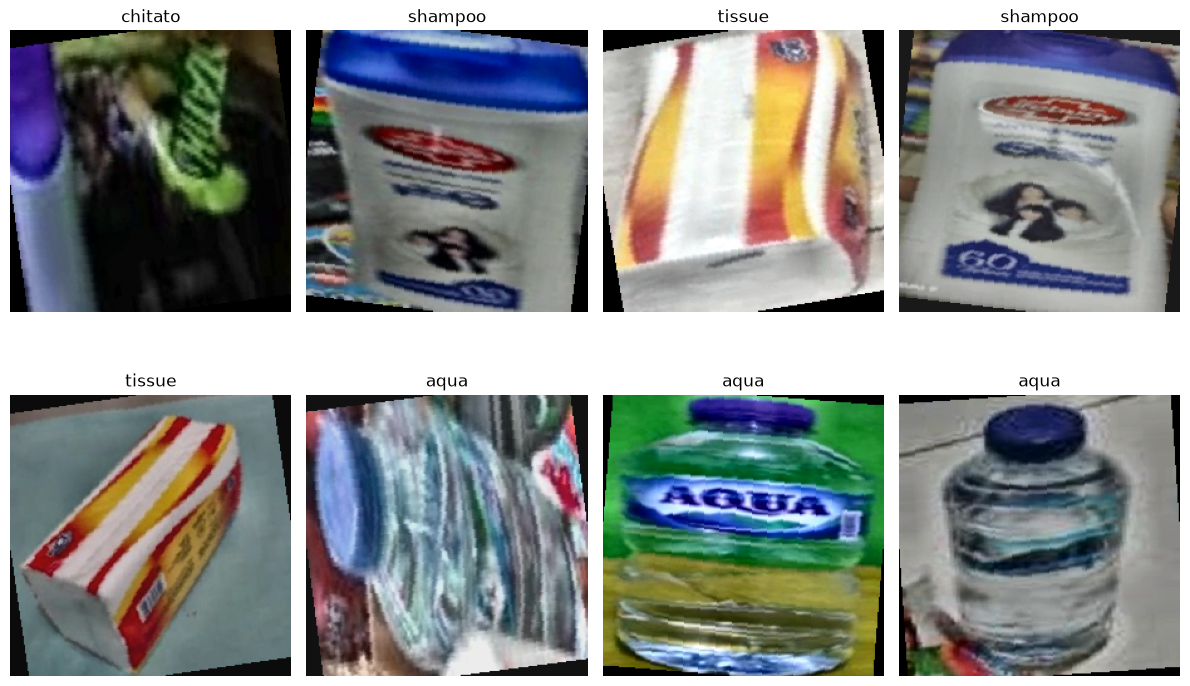

In [9]:
plt.figure(figsize=(12, 8))

for i in range(8):

    image = images[i].permute(
        1, 2, 0
    ).numpy()

    label = labels[i].item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(train_dataset.classes[label])

plt.tight_layout()
plt.show()

In [10]:
import torch.nn as nn

class RetailCNN(nn.Module):

    def __init__(self, num_classes=6):
        super().__init__()

        # Convolutional feature extraction
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Classification layers
        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 28 * 28,
                256
            ),

            nn.ReLU(),

            nn.Dropout(
                p=0.5
            ),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [11]:
model = RetailCNN(
    num_classes=len(train_dataset.classes)
)

model = model.to(device)

print(model)

RetailCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=6, bias=True)
  )
)


In [12]:
sample_batch, sample_labels = next(
    iter(train_loader)
)

sample_batch = sample_batch.to(device)

with torch.no_grad():
    output = model(sample_batch)

print("Input shape:", sample_batch.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 6])


In [13]:
import torch.nn as nn

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [14]:
num_epochs = 10

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = (
        running_train_loss / len(train_loader)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = (
        running_val_loss / len(val_loader)
    )

    epoch_val_accuracy = (
        correct / total
    ) * 100

    # Save history
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Accuracy: {epoch_val_accuracy:.2f}%"
    )

Epoch [1/10] Train Loss: 1.7483 | Val Loss: 1.3459 | Val Accuracy: 45.61%
Epoch [2/10] Train Loss: 1.2831 | Val Loss: 0.8300 | Val Accuracy: 73.68%
Epoch [3/10] Train Loss: 1.0065 | Val Loss: 0.7663 | Val Accuracy: 69.30%
Epoch [4/10] Train Loss: 0.7912 | Val Loss: 0.6178 | Val Accuracy: 74.56%
Epoch [5/10] Train Loss: 0.7576 | Val Loss: 0.4631 | Val Accuracy: 82.46%
Epoch [6/10] Train Loss: 0.4974 | Val Loss: 0.4063 | Val Accuracy: 84.21%
Epoch [7/10] Train Loss: 0.5616 | Val Loss: 0.5164 | Val Accuracy: 79.82%
Epoch [8/10] Train Loss: 0.5197 | Val Loss: 0.6653 | Val Accuracy: 71.93%
Epoch [9/10] Train Loss: 0.4692 | Val Loss: 0.3989 | Val Accuracy: 83.33%
Epoch [10/10] Train Loss: 0.5615 | Val Loss: 0.4821 | Val Accuracy: 80.70%


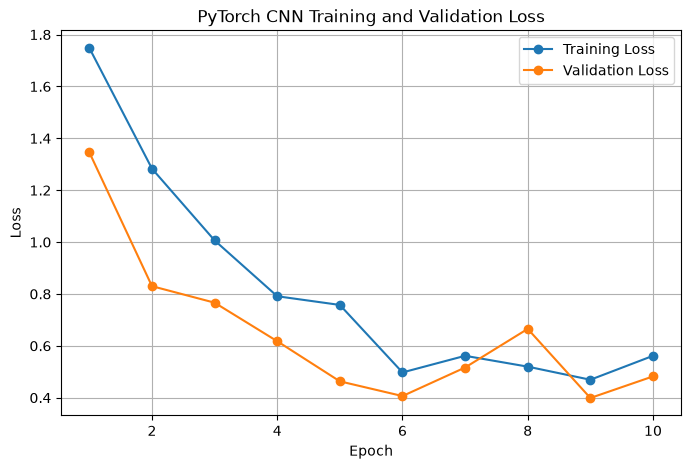

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, num_epochs + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch CNN Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

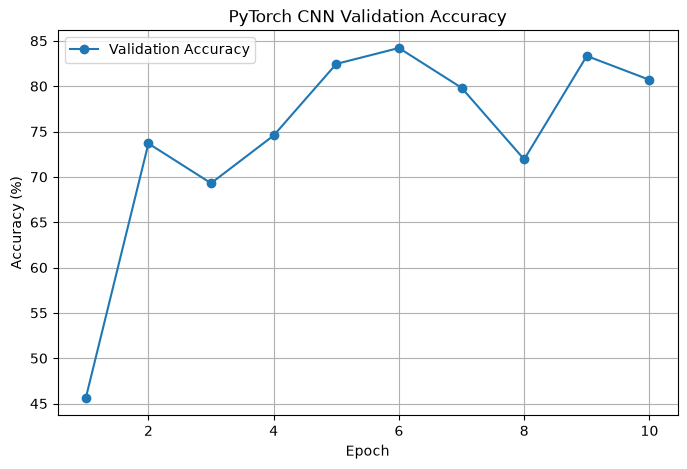

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("PyTorch CNN Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
# Evaluate CNN on the test set

model.eval()

correct = 0
total = 0

test_loss = 0.0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Model prediction
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


test_loss = test_loss / len(test_loader)

test_accuracy = (correct / total) * 100

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.7555
Test Accuracy: 74.07%


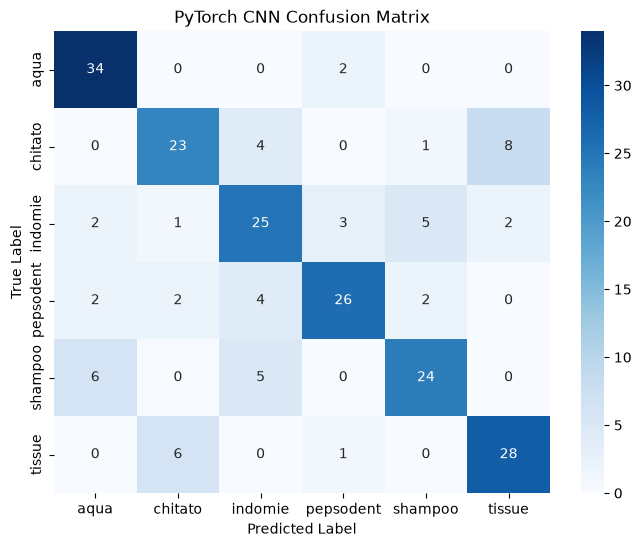

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Store predictions and true labels
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

# Create confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

# Plot
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("PyTorch CNN Confusion Matrix")

plt.show()

In [19]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes,
    digits=4
)

print(report)

              precision    recall  f1-score   support

        aqua     0.7727    0.9444    0.8500        36
     chitato     0.7188    0.6389    0.6765        36
     indomie     0.6579    0.6579    0.6579        38
   pepsodent     0.8125    0.7222    0.7647        36
     shampoo     0.7500    0.6857    0.7164        35
      tissue     0.7368    0.8000    0.7671        35

    accuracy                         0.7407       216
   macro avg     0.7415    0.7415    0.7388       216
weighted avg     0.7407    0.7407    0.7380       216



In [20]:
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

model_path = model_dir / "retail_cnn_pytorch.pth"

torch.save(
    model.state_dict(),
    model_path
)

print("Model saved to:", model_path)

Model saved to: ..\models\retail_cnn_pytorch.pth


In [21]:
num_epochs = 10

best_val_accuracy = 0.0

best_model_path = "../models/retail_cnn_pytorch_best.pth"

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = (
        running_train_loss / len(train_loader)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    epoch_val_loss = (
        running_val_loss / len(val_loader)
    )

    epoch_val_accuracy = (
        correct / total
    ) * 100

    # Save history
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    # -------------------------
    # Save best model
    # -------------------------
    if epoch_val_accuracy > best_val_accuracy:

        best_val_accuracy = epoch_val_accuracy

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Accuracy: {epoch_val_accuracy:.2f}% "
            f"← BEST MODEL SAVED"
        )

    else:

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Accuracy: {epoch_val_accuracy:.2f}%"
        )

print("\nBest validation accuracy:", f"{best_val_accuracy:.2f}%")
print("Best model saved to:", best_model_path)

Epoch [1/10] Train Loss: 0.3668 | Val Loss: 0.4497 | Val Accuracy: 83.33% ← BEST MODEL SAVED
Epoch [2/10] Train Loss: 0.3150 | Val Loss: 0.5032 | Val Accuracy: 81.58%
Epoch [3/10] Train Loss: 0.3404 | Val Loss: 0.5401 | Val Accuracy: 80.70%
Epoch [4/10] Train Loss: 0.3460 | Val Loss: 0.4191 | Val Accuracy: 82.46%
Epoch [5/10] Train Loss: 0.2884 | Val Loss: 0.4782 | Val Accuracy: 81.58%
Epoch [6/10] Train Loss: 0.3278 | Val Loss: 0.4596 | Val Accuracy: 84.21% ← BEST MODEL SAVED
Epoch [7/10] Train Loss: 0.2741 | Val Loss: 0.5941 | Val Accuracy: 81.58%
Epoch [8/10] Train Loss: 0.2547 | Val Loss: 0.5455 | Val Accuracy: 88.60% ← BEST MODEL SAVED
Epoch [9/10] Train Loss: 0.1785 | Val Loss: 0.5396 | Val Accuracy: 84.21%
Epoch [10/10] Train Loss: 0.2174 | Val Loss: 0.4798 | Val Accuracy: 83.33%

Best validation accuracy: 88.60%
Best model saved to: ../models/retail_cnn_pytorch_best.pth


In [22]:
# Load the best validation model

best_model = RetailCNN(
    num_classes=len(train_dataset.classes)
)

best_model = best_model.to(device)

best_model.load_state_dict(
    torch.load(
        "../models/retail_cnn_pytorch_best.pth",
        map_location=device
    )
)

best_model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [23]:
# Generate predictions on the test set

all_test_predictions = []
all_test_labels = []

best_model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = best_model(images)

        _, predicted = torch.max(outputs, 1)

        all_test_predictions.extend(
            predicted.cpu().numpy()
        )

        all_test_labels.extend(
            labels.numpy()
        )

print("Total test images:", len(all_test_labels))
print("Total predictions:", len(all_test_predictions))

Total test images: 216
Total predictions: 216


In [24]:
from sklearn.metrics import accuracy_score

best_test_accuracy = accuracy_score(
    all_test_labels,
    all_test_predictions
)

print(
    f"Best Model Test Accuracy: "
    f"{best_test_accuracy * 100:.2f}%"
)

Best Model Test Accuracy: 76.39%


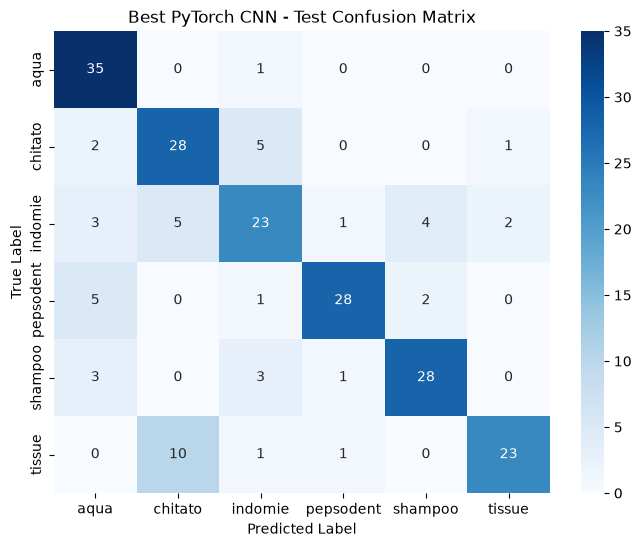

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix for the best model
best_cm = confusion_matrix(
    all_test_labels,
    all_test_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Best PyTorch CNN - Test Confusion Matrix")

plt.show()

In [26]:
from sklearn.metrics import classification_report

best_report = classification_report(
    all_test_labels,
    all_test_predictions,
    target_names=test_dataset.classes,
    digits=4
)

print(best_report)

              precision    recall  f1-score   support

        aqua     0.7292    0.9722    0.8333        36
     chitato     0.6512    0.7778    0.7089        36
     indomie     0.6765    0.6053    0.6389        38
   pepsodent     0.9032    0.7778    0.8358        36
     shampoo     0.8235    0.8000    0.8116        35
      tissue     0.8846    0.6571    0.7541        35

    accuracy                         0.7639       216
   macro avg     0.7780    0.7650    0.7638       216
weighted avg     0.7764    0.7639    0.7624       216

